<a href="https://colab.research.google.com/github/massefi/AgenticAI/blob/main/AgenticAIChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Competitor Analysis Using Multi-Agent Retrieval-Augmented Generation (RAG) Collaborative System**

## **Business Context**

Performing competitor analysis with a Multi-Agent Retrieval-Augmented Generation (RAG) Collaborative System.

# **Problem Scenario**

Conducting a robust competitor analysis of a company is a time-consuming and research-intensive process that may be prone to errors for example, outdated information.

Analysts spend significant time gathering data, identifying relevant competitors, and synthesizing insights into actionable recommendations.

# **Objective**

To address above mentioned challenges, a Multi-Agent Retrieval-Augmented Generation (RAG) Collaborative System is proposed.

This system will perform competitor analysis of a given company by comparing it with its key rivals in the relevant industry using the latest available web data.

Users will input a company name (e.g., "Tesla") and receive a well-structured report, comparing that company to its primary competitors (e.g., in the electric vehicle sector for Tesla), by leveraging a multi-agent collaborative architecture powered by RAG capabilities.

The system should deliver rapid, accurate, and actionable insights.

# **Solution Approach**

A Multi-Agent Retrieval-Augmented Generation (RAG) Collaborative System shall be implemented using a sequential workflow pattern.

This system shall automate a competitor analysis by breaking down the task into distinct steps handled by specialized agents.

The sequential pattern ensures each step builds on the previous one. Also, incorporating RAG to retrieve and augment data from a vector database for context-aware insights.

Below are the key components of the implementation:

# **State Management**

The workflow shall use a Pydantic-based state CompetitiveAnalysisState to track variables like company name, generated questions, search results, vectorstore status, and the final report.

# **Required Tools**

* suggest_questions: Generates relevant questions for competitor analysis using
the LLM.
* fetch_search_results: Searches the web via Tavily API to fetch answers for the questions.
* store_in_chromadb: Stores question-answer pairs in ChromaDB for efficient retrieval.
* generate_report: Uses RAG to query the vectorstore and draft a structured report.




# **Required Agents**

* Question Generator Agent: Validates the company, identifies its sector, and generates analysis questions.

* Data Retrieval and Storage Agent: Fetches answers from the web and stores them in the vector database.

* Report Drafter Agent: Retrieves stored data via RAG and generates a professional, actionable report with sections like Executive Summary, Company Overview, Key Competitors, Strengths/Weaknesses, Market Strategies, and Recommendations.

# **Workflow (Sequential Pattern)**

The system shall use a LangGraph's StateGraph to define nodes for each agent. Edges connect the nodes sequentially as indicated below.

START -> Question Generation -> Data Retrieval/Storage -> Report Drafting -> END.

The final output is a formatted competitive analysis report, displayed in Markdown for readability.

# **Installing the Libraries**

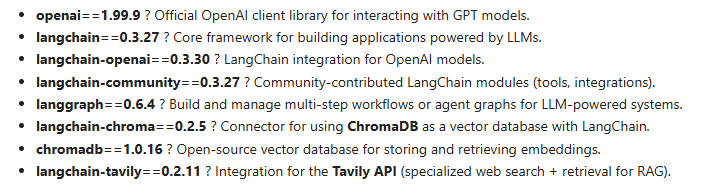

In [1]:
#Install required packages
!pip install -q openai==1.99.9 \
                langchain==0.3.27 \
                langchain-openai==0.3.30 \
                langchain-community==0.3.27 \
                langgraph==0.6.4 \
                langchain-chroma==0.2.5 \
                chromadb==1.0.16 \
                langchain-tavily==0.2.11

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.8/786.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.2/153.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2

# **Setting up the Environment**

## Importing the relevant packages

In [2]:
import os
import json
import random
import datetime

from enum import Enum
from typing import TypedDict, List, Optional, Dict, Tuple, Any

from pydantic import BaseModel, Field,ConfigDict

import chromadb

from langchain_core.tools import tool
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import StructuredTool
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.retrievers import BaseRetriever
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import create_react_agent
from langchain_tavily import TavilySearch

from IPython.display import Image, display, Markdown

from google.colab import userdata

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## **Instantiating the required variables (5 Marks)**

Set the environment variables.

To securely connect with external APIs (like OpenAI and Tavily), we'll set up our** environment variables**.
This ensures our API keys are not hard-coded directly in the notebook, keeping them safe.

*   **OPENAI_API_KEY**
*   **OPENAI_BASE_URL**
*   **TAVILY_API_KEY**

After running this cell, your notebook will be able to access both **OpenAI** and **Tavily APIs** securely.

In [3]:
# Set environment variables
openai_api_key = userdata.get('my_mit_test_key')
os.environ["OPENAI_API_KEY"] = userdata.get('my_mit_test_key')
os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')
os.environ['OPENAI_BASE_URL'] = "https://api.openai.com/v1"

Now that our environment variables are set, let's initialize the core models we'll use in this project:

Instantiating the LLM and the embedding model using the ChatOpenAI and OpenAIEmbeddings methods respectively.

In [4]:
#Initialize ChatOpenAI LLM with foundational {Model} of choice and temp 0.
#Comment on model of choice and the importance of the temp parameter.

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
#llm =
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)
# Initialize OpenAIEmbeddings for generating text embeddings.

#embedding_model =
embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

To enable **Retrieval-Augmented Generation (RAG)**, we need a place to store and query text embeddings.
Here, we'll use **ChromaDB**, an open-source vector database.

Setting up the Chroma vector database client and a Chroma vector store collection for storing and retrieving search results.

In [5]:
# ChromaDB set up Persistent client
import chromadb
from langchain_chroma import Chroma
# The following code shall persists the data in the local disk
#chromadb_client =
CHROMA_DB_DIR = "./chroma_competitor_analysis"

chromadb_client = chromadb.PersistentClient(
    path=CHROMA_DB_DIR
)
# Set up Chroma vectorstore using the above embedding model
#vectorstore =
vectorstore = Chroma(
    client=chromadb_client,
    collection_name="competitor_analysis",
    embedding_function=embedding_model,
)

## **State Definitions**

Lets define the Pydantic models for structured outputs: -> 'QuestionSuggestion' and the overall state: -> 'CompetitiveAnalysisState' .

State Definition ensure type safety and structure the data passed between agents and nodes.

# **QuestionSuggestion**

This model will help ensure that the responses from the LLM follow a consistent format, making them easier to validate and use later.

* Create a class that inherits from BaseModel.

* Fields shall include:

  * **sector**: The industry sector of the company.
  * **is_valid_company**: A boolean flag for whether the company name is recognized.
  * **questions**: A list of suggested competitive analysis questions.
  * **error_message**: Optional field to capture any errors that occur.
* The Field() argument ensures that **default values** and **descriptions** are available for each attribute.

In [ ]:
from typing import List, Optional
from pydantic import BaseModel, Field


class QuestionSuggestion(BaseModel):
    """
    Structured output model for competitive analysis questions.
    This ensures the LLM returns predictable and validated fields.
    """

    sector: str = Field(
        default="",
        description="The industry sector of the company, for example Electric Vehicles, Cloud Computing, or Retail."
    )

    is_valid_company: bool = Field(
        default=False,
        description="Boolean flag indicating whether the provided company name is recognized as a valid company."
    )

    questions: List[str] = Field(
        default_factory=list,
        description="List of suggested competitive analysis questions for the given company."
        # min_length=5,
        # max_length=12,
        # description="List of 5 to 12 competitive analysis questions for the given company."
    )

    # competitors: list[str] = Field(
    # default_factory=list,
    # description="Initial list of likely competitors for the company."
    # )

    error_message: Optional[str] = Field(
        default=None,
        description="Optional error message if the company is invalid or question generation fails."
    )

## **Competitive Analysis State**

Next, we'll create a state object for keeping track off the competitive analysis that keeps track of all the information our pipeline generates and updates during the competitive analysis workflow.

This will act as a ***shared memory*** object, making it easier to pass data between steps in the system.

* Fields to include:

  * **company_name** ? The company being analyzed.
  * **max_num_of_questions** ? The maximum number of questions to generate (use a constant as the default).
  * **sector** ? The industry sector (optional).
  is_valid_company ? Boolean flag to mark if the company is recognized (optional).
  * **question_list** ? List of generated analysis questions (optional).
  * **qna_results** ? Stores answers to questions as a list of dictionaries (optional).
  * **vectorstore** ? Chroma vector database instance for retrieval.
  **chromadb_insert_status** ? Tracks whether data was successfully stored in Chroma (optional).
  * **report** ? Final competitive analysis report (optional).
  * **error_message** ? Captures any error details (optional).
* The model_config setting allows non-Pydantic types (e.g., Chroma objects).

In [ ]:
#Setting maximum limit to number of genetated questions
from enum import Enum
from typing import Any, Dict, List, Optional

from pydantic import BaseModel, ConfigDict, Field
from langchain_chroma import Chroma


# Setting maximum limit to number of generated questions
MAX_NUM_OF_QUESTIONS = 40

In [ ]:
class InsertStatus(str, Enum):
    NOT_STARTED = "not_started"
    SUCCESS = "success"
    FAILED = "failed"

In [ ]:
from enum import Enum
from typing import Any, Dict, List, Optional

from pydantic import BaseModel, ConfigDict, Field
from langchain_chroma import Chroma


MAX_NUM_OF_QUESTIONS = 40


class InsertStatus(str, Enum):
    NOT_STARTED = "not_started"
    SUCCESS = "success"
    FAILED = "failed"


class CompetitiveAnalysisState(BaseModel):
    """
    Structured output model for competitive analysis state.
    """

    model_config = ConfigDict(arbitrary_types_allowed=True)

    company_name: str = Field(
        description="The company being analyzed."
    )

    max_num_of_questions: int = Field(
        default=MAX_NUM_OF_QUESTIONS,
        description="Maximum number of competitive analysis questions to generate."
    )

    sector: Optional[str] = Field(
        default=None,
        description="The industry sector of the company."
    )

    is_valid_company: Optional[bool] = Field(
        default=None,
        description="Boolean flag indicating whether the company name is recognized."
    )

    question_list: List[str] = Field(
        default_factory=list,
        description="List of generated competitive analysis questions."
    )

    qna_results: List[Dict[str, Any]] = Field(
        default_factory=list,
        description="List of dictionaries containing question-answer search results."
    )

    vectorstore: Optional[Chroma] = Field(
        default=None,
        description="Chroma vector database instance used for retrieval."
    )

    chromadb_insert_status: InsertStatus = Field(
        default=InsertStatus.NOT_STARTED,
        description="Tracks whether data was successfully stored in ChromaDB."
    )

    report: Optional[str] = Field(
        default=None,
        description="Final competitive analysis report."
    )

    error_message: Optional[str] = Field(
        default=None,
        description="Captures error details if any workflow step fails."
    )

# **Tools**

### **Tavily Search Tool (1 Mark)**

To enrich our competitive analysis, **Tavily Search** will be used to fetch **relevant company information** that can later be embedded into our vector store and used for RAG. The following code

* Initializes a TavilySearch instance with the following parameters:
  * **max_results** ? The maximum number of results to return
  * **include_answer** ? Whether to include a synthesized answer from Tavily.
  * **include_raw_content** ? Whether to return raw page content along with the results.
  * **search_depth** ? Set the level of search ("basic" or "advanced").

In [ ]:
from langchain_tavily import TavilySearch


# Initialize TavilySearch for retrieving up-to-date web information.
# max_results controls how many search results are returned.
# include_answer=True asks Tavily to provide a synthesized answer.
# include_raw_content=False keeps responses smaller and easier to store.
# search_depth="advanced" performs a deeper search, useful for competitor analysis.

#search =
search = TavilySearch(
    max_results=5,
    include_answer=True,
    include_raw_content=False,
    search_depth="advanced"
)

***Testing the tool!***

In [ ]:
response = search.invoke({
    "query": "Tesla main competitors in electric vehicle market 2026"
})

response

{'query': 'Tesla main competitors in electric vehicle market 2026',
 'follow_up_questions': None,
 'answer': "Tesla's main competitors in the 2026 electric vehicle market include Rivian, Lucid Group, and General Motors. Hyundai and Kia also pose significant competition, especially in value and charging speed. The market is increasingly competitive as alternatives improve.",
 'images': [],
 'results': [{'url': 'https://hudson-labs.com/research/tesla-competitors-tsla',
   'title': "Tesla's Top Competitors and Peers in 2026",
   'content': 'Major Tesla Competitors and Peers\n\n   Lucid Group Inc. ($LCID)\n\nCompetes directly with Tesla and Rivian, focusing on luxury, range, efficiency, and advanced technology. Lucid positions itself as the “natural successor” for Tesla Model S and Model X customers.\n\n   Rivian Automotive, Inc. ($RIVN)\n\nDifferentiates through vertically integrated technology, direct-to-customer relationships, and a focus on adventure-oriented vehicles and commercial EV

Below section defines the tools used by the agents for,

* Suggesting questions,
* Fetching search results,
* Storing data in ChromaDB, and
* Generating the report.




# **Suggest Questions Tool (3 marks)**

The Suggest Questions Tool shall be built as a custom LangChain tool that uses an LLM to generate structured competitive analysis questions for a given company.

This tool will serve as the **entry point** in our pipeline for validating company information and generating insightful prompts for deeper analysis.

The function suggest_questions shall contains a prompt that instructs the LLM to: - Validate if the company is real/known.
- Identify its sector.
- Generate targeted competitor analysis questions (e.g., competitors, pricing, supply chain, strengths/weaknesses, market opportunities) and invokes the LLM with a structured output format (using the QuestionSuggestion model).
Ensure that it can be called by agents within LangChain.

In [ ]:
import json
from langchain_core.tools import tool

# Define function as a LangChain Tool.
# Define company name and max_num_of_questions as inputs using type hinting
# Define function output as string using type hinting
@tool
def suggest_questions(company_name: str, max_num_of_questions: int = MAX_NUM_OF_QUESTIONS) -> str:
    """
    Suggest list containing competitive analysis questions for the given company name.

    Args:
        company_name: Name of the company to analyze.
        max_num_of_questions: Maximum number of questions to generate.

    Returns:
        A JSON string containing sector, validity flag, questions, and error message.
    """

    prompt = f"""
    You are a senior business analyst helping with competitor analysis.

    For the given company name: {company_name}

    Your tasks are:
1. Determine whether the company is real, recognizable, and suitable for competitor analysis.
2. Identify the company's primary industry sector.
3. Generate up to {max_num_of_questions} targeted competitor-analysis questions.
4. Ensure the questions help compare the company against its key direct and indirect competitors.
5. Make the questions specific, business-relevant, and useful for creating a professional competitor analysis report.

A company is considered valid if:
- It appears to be a real business, brand, or organization.
- It has enough publicly available information for meaningful competitor analysis.
- It is not merely a vague term, product category, fictional name, or unsupported phrase.

The questions should cover relevant areas such as:
- Main competitors
- Market share and market position
- Products or services
- Pricing strategy
- Revenue and financial performance
- Strengths and weaknesses
- Customer perception and brand reputation
- Supply chain or operations
- Innovation and technology
- Marketing and sales strategy
- Growth opportunities
- Competitive threats
- Strategic recommendations

Return the response using the required structured format with these fields:
- sector
- is_valid_company
- questions
- error_message

Rules:
- If the company is valid, set is_valid_company to true.
- If the company is valid, provide a clear sector.
- If the company is valid, generate a useful list of competitor-analysis questions.
- If the company is invalid, ambiguous, fictional, or not recognized:
  - Set is_valid_company to false.
  - Set sector to an empty string.
  - Return an empty questions list.
  - Provide a clear error_message.
- Do not invent facts about unknown companies.
- Do not include explanations outside the required structured format.
"""

    print("[INSIDE TOOL] suggest_questions")

#try:
        # Invoke the LLM with structured output enforcement with the appropriate Pydantic model
        # This shall returns a Pydantic object (not raw text) if the model and wrapper support it
        #result =
        #print(f"[Identified SECTOR] {result.sector}")
        #sector =
        #print(f"[IS VALID COMPANY] {result.is_valid_company}")
        #is_valid_company =
        #print(f"[QUESTION GENERATED LIST] {result.questions}")
        #questions_list =
        #return
        #except Exception as e:
    try:

        structured_llm = llm.with_structured_output(QuestionSuggestion)
        result = structured_llm.invoke(prompt)
        print(f"[Identified SECTOR] {result.sector}")
        print(f"[IS VALID COMPANY] {result.is_valid_company}")
        print(f"[QUESTION GENERATED LIST] {result.questions}")
        sector = result.sector
        is_valid_company = result.is_valid_company
        questions_list = result.questions
        return result.model_dump_json(indent=2)

    except Exception as e:
        error_response = QuestionSuggestion(
            sector="",
            is_valid_company=False,
            questions=[],
            error_message=f"Question suggestion failed: {str(e)}"
        )

        return error_response.model_dump_json(indent=2)

# **Testing!!!**

In [ ]:
result = suggest_questions.invoke({
    "company_name": "Tesla",
    "max_num_of_questions": 5
})

print(result)

[INSIDE TOOL] suggest_questions
[Identified SECTOR] Electric Vehicles and Clean Energy
[IS VALID COMPANY] True
[QUESTION GENERATED LIST] ["Who are Tesla's main direct and indirect competitors in the electric vehicle and clean energy markets, and how do their market shares compare?", "How does Tesla's product portfolio, including electric vehicles, energy storage, and solar products, differentiate from its competitors?", "What are Tesla's pricing strategies relative to competitors, and how do these impact its market positioning and profitability?", "How do Tesla's innovation capabilities and technology advancements compare to those of its key competitors?", "What are the strengths and weaknesses of Tesla's supply chain and manufacturing operations compared to its competitors, and how do these affect its competitive advantage?"]
{
  "sector": "Electric Vehicles and Clean Energy",
  "is_valid_company": true,
  "questions": [
    "Who are Tesla's main direct and indirect competitors in the

## **Fetch Search Result Tool**

The Fetch Search Result tool will take each question, query the **Tavily Search API**, and collect the results.

The function **iterates** through the question_list and for each question: - Call search.invoke({"query": question}) to get Tavily search results.
- Check if the result contains an "answer".
- Store the pair (question, answer) in a list of dictionaries.
Additionally, the function shall:

* **Handle missing answers** by storing an empty string.
* **Handle errors** with a try/except block and log them for debugging.
* Return the **final results as a JSON string**.

In [ ]:
# Define function as a LangChain Tool
# Define question_list as an input list and output string using type hinting
import json
from typing import List
from langchain_core.tools import tool


@tool
def fetch_search_results(question_list: List[str]) -> str:
    """
    Iterate through question_list and, for each question, search for answers using Tavily Search API.

    Args:
        question_list: List of competitive analysis questions.

    Returns:
        JSON string containing a list of dictionaries with question and answer.
    """

    print("[INSIDE TOOL]: fetch_search_results")

    results = []

    # Itertate through the list of questions and process using the search tool

    for question in question_list:
         #try:
            #print("[QUESTION]:", question)
        try:
            print("[QUESTION]:", question)

            # Invoke the Tavily search tool
   #         search_result =
            search_result = search.invoke({
                "query": question
            })
            #print("[SEARCH RESULT]:", search_result)
            print("[SEARCH RESULT]:", search_result)

            # Tavily usually returns a dictionary containing an "answer" field.
            # If no answer is available, store an empty string.
            answer = ""

            if isinstance(search_result, dict):
                answer = search_result.get("answer", "") or ""
            else:
                answer = str(search_result)

            results.append({
                "question": question,
                "answer": answer
            })

        except Exception as e:
            print(f"[ERROR] Failed to fetch result for question: {question}")
            print(f"[ERROR DETAILS]: {str(e)}")

            results.append({
                "question": question,
                "answer": "",
                "error": str(e)
            })

    return json.dumps(results, indent=2)

**Testing the tool!!!**

In [ ]:
sample_questions = [
    "Who are Tesla's main competitors in the electric vehicle market?",
    "How does Tesla's pricing strategy compare with BYD and Ford?"
]

search_results_json = fetch_search_results.invoke({
    "question_list": sample_questions
})

print(search_results_json)

[INSIDE TOOL]: fetch_search_results
[QUESTION]: Who are Tesla's main competitors in the electric vehicle market?
[SEARCH RESULT]: {'query': "Who are Tesla's main competitors in the electric vehicle market?", 'follow_up_questions': None, 'answer': "Tesla's main competitors in the electric vehicle market include BYD, Ford, General Motors, and Rivian Automotive. BYD leads in global EV sales, while Ford, GM, and Rivian are significant players in the U.S. market.", 'images': [], 'results': [{'url': 'https://www.investopedia.com/ask/answers/120314/who-are-teslas-tsla-main-competitors.asp', 'title': "What Are Tesla's (TSLA) Main Competitors? - Investopedia", 'content': 'Spencer Platt/Staff / Getty Images\n\nClose\n\nIn the electric vehicle (EV) market, one name has long dominated headlines and has often been synonymous with EVs in the public mind: Tesla (TSLA). In recent years, established automakers and ambitious startups have moved into the fast lane with their EV programs in response to cl

# **Store in ChromaDB Tool**

After fetching question-answer pairs, they must be stored in ChromaDB so they can later be retrieved during the analysis.
This tool will embed the answers and insert them into the vector store along with metadata for traceability.

The function store_in_chromadb:

* Loop through each question/answer dictionary.
* **Skip empty answers** (don't embed/store them).
* For valid answers:
  * Create a documents list containing the answer text.
  * Create metadatas with fields such as:
    * question ? the original question
    * source_type ? "answer"
    * search_success ? whether a valid answer was found
  * Create unique ids for each entry (e.g., "doc_1", "doc_2").
*Use vectorstore.add_texts() to insert documents, metadata, and IDs into ChromaDB.

In [ ]:
# Define function as a LangChain Tool
# Define "qna_results" as a input list of dictionaries and output string using type hinting

import json
import uuid
from typing import Any, Dict, List
from langchain_core.tools import tool


@tool
def store_in_chromadb(qna_results: List[Dict[str, Any]]) -> str:
    """
    Stores a list of question-answer dictionaries in a ChromaDB vectorstore after embedding.

    Args:
        qna_results: List of dictionaries containing question-answer pairs.

    Returns:
        JSON string indicating success or failure.
    """

    print("[INSIDE TOOL]: store_in_chromadb")

    success_count = 0
    skipped_count = 0
    failed_count = 0
    error_messages = []

    # Iterate over the list containing Q&A results
    for index, d in enumerate(qna_results, start=1):
        try:
            question = d.get("question", "")
            answer = d.get("answer", "")

            # Skip empty answers because there is no useful text to embed/store
            if not answer:
                print(f"[SKIPPED]: Empty answer for question: {question}")
                skipped_count += 1
                continue

            # Create documents list containing the answer text
            documents = [answer]

            # Create metadata for traceability
            metadatas = [
                {
                    "question": question,
                    "source_type": "answer",
                    "search_success": True
                }
            ]

            # Create unique ID for each document
            # uuid is added to avoid duplicate ID errors if this cell is run multiple times
            ids = [f"doc_{index}_{uuid.uuid4().hex[:8]}"]

            print("[DOCUMENTS]:", documents)
            print("[METADATA]:", metadatas)
            print("[IDS]:", ids)

            # Add documents, metadata, and ids to the vectorstore
            vectorstore.add_texts(
                texts=documents,
                metadatas=metadatas,
                ids=ids
            )

            success_count += 1
            print(f"[SUCCESS]: Added entry for question: {question}")

        except Exception as e:
            failed_count += 1
            error_message = f"Failed to add entry for question '{d.get('question', '')}': {str(e)}"
            error_messages.append(error_message)
            print("[ERROR]:", error_message)

    # Set ChromaDB insert status
    if success_count > 0 and failed_count == 0:
        chromadb_insert_status = InsertStatus.SUCCESS
    elif success_count > 0 and failed_count > 0:
        chromadb_insert_status = InsertStatus.SUCCESS
    else:
        chromadb_insert_status = InsertStatus.FAILED

    # Return the ChromaDB insert status as a JSON string
    return json.dumps(
        {
            "chromadb_insert_status": chromadb_insert_status.value,
            "success_count": success_count,
            "skipped_count": skipped_count,
            "failed_count": failed_count,
            "error_messages": error_messages
        },
        indent=2
    )

# **Testing ChromDB Query**

In [ ]:
sample_qna_results = [
    {
        "question": "Who are Tesla's main competitors?",
        "answer": "Tesla's main competitors include BYD, Ford, General Motors, Hyundai, and Volkswagen."
    },
    {
        "question": "What is Tesla's pricing strategy?",
        "answer": "Tesla uses a dynamic pricing strategy and frequently adjusts prices based on demand, production costs, and competitive pressure."
    },
    {
        "question": "Empty test question",
        "answer": ""
    }
]

insert_status_json = store_in_chromadb.invoke({
    "qna_results": sample_qna_results
})

print(insert_status_json)

[INSIDE TOOL]: store_in_chromadb
[DOCUMENTS]: ["Tesla's main competitors include BYD, Ford, General Motors, Hyundai, and Volkswagen."]
[METADATA]: [{'question': "Who are Tesla's main competitors?", 'source_type': 'answer', 'search_success': True}]
[IDS]: ['doc_1_724ee150']
[SUCCESS]: Added entry for question: Who are Tesla's main competitors?
[DOCUMENTS]: ['Tesla uses a dynamic pricing strategy and frequently adjusts prices based on demand, production costs, and competitive pressure.']
[METADATA]: [{'question': "What is Tesla's pricing strategy?", 'source_type': 'answer', 'search_success': True}]
[IDS]: ['doc_2_a6bb6bb4']
[SUCCESS]: Added entry for question: What is Tesla's pricing strategy?
[SKIPPED]: Empty answer for question: Empty test question
{
  "chromadb_insert_status": "success",
  "success_count": 2,
  "skipped_count": 1,
  "failed_count": 0,
  "error_messages": []
}


In [ ]:
stored_data = vectorstore.get(
    include=["documents", "metadatas"]
)

print("Total stored documents:", len(stored_data["ids"]))

for i, doc_id in enumerate(stored_data["ids"][:10]):  #just 10 records to be printed, remove [:10] to check the entire DB
    print("\n" + "=" * 80)
    print("ID:", doc_id)
    print("Metadata:", stored_data["metadatas"][i])
    print("Document:")
    print(stored_data["documents"][i])

Total stored documents: 2

ID: doc_1_724ee150
Metadata: {'search_success': True, 'question': "Who are Tesla's main competitors?", 'source_type': 'answer'}
Document:
Tesla's main competitors include BYD, Ford, General Motors, Hyundai, and Volkswagen.

ID: doc_2_a6bb6bb4
Metadata: {'source_type': 'answer', 'question': "What is Tesla's pricing strategy?", 'search_success': True}
Document:
Tesla uses a dynamic pricing strategy and frequently adjusts prices based on demand, production costs, and competitive pressure.


# **Generate Report Tool**

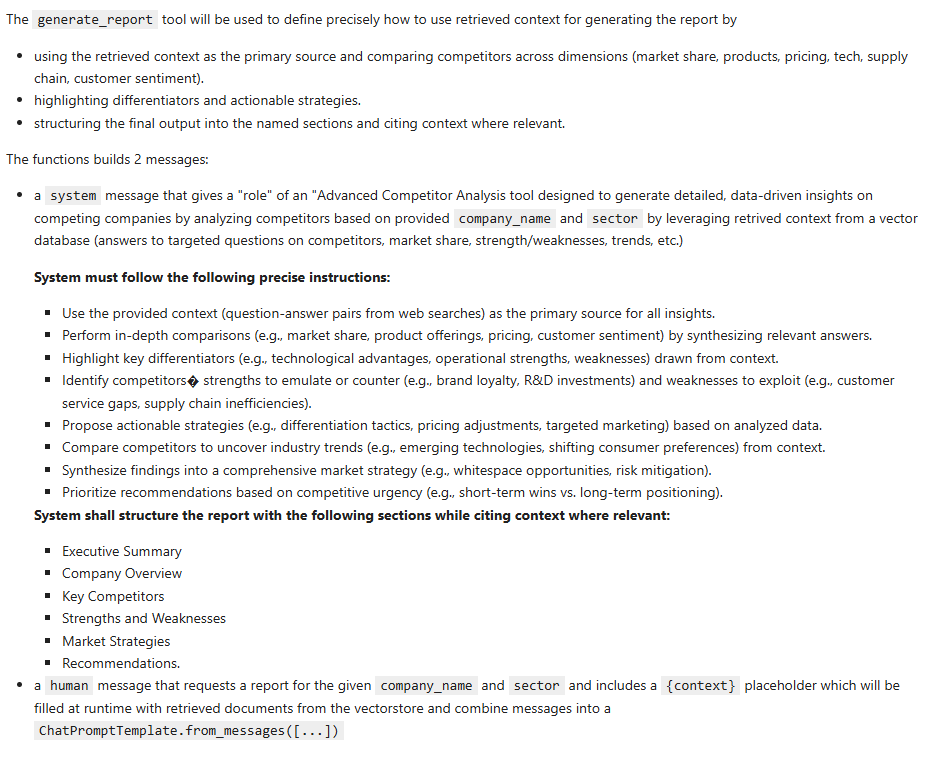

In [ ]:
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


@tool
def generate_report(company_name: str, sector: str, context: str) -> str:
    """
    Generate a Markdown competitive analysis report using pre-retrieved RAG context.

    This tool expects the caller to provide context retrieved from ChromaDB,
    usually question-answer pairs with source metadata. It does not query the
    vectorstore directly.

    Args:
        company_name: Name of the company being analyzed.
        sector: Industry sector of the company.
        context: Retrieved RAG context from ChromaDB, preferably including
            question-answer pairs, source URLs, titles, and retrieval dates.

    Returns:
        A Markdown-formatted competitive analysis report grounded in the
        provided context.
    """

    print("[INSIDE TOOL]: generate_report")

    company_name = company_name.strip()
    sector = sector.strip()
    context = context.strip()

    if not company_name:
        return "Error: company_name is required."

    if not sector:
        return "Error: sector is required."

    if not context:
        return (
            "# Competitive Analysis Report\n\n"
            "Unable to generate a reliable competitive analysis report because "
            "no retrieved context was provided."
        )

    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """
You are a senior business analyst specializing in competitor analysis.

Your task is to generate a professional, evidence-grounded competitive analysis
report using only the retrieved RAG context provided by the user.

Core rules:
1. Use the retrieved context as the primary source of evidence.
2. Do not invent competitors, facts, financial figures, market share values,
   customer sentiment, or strategic claims that are not supported by the context.
3. If the context is incomplete, clearly identify missing information.
4. If a claim is uncertain, state it as uncertain.
5. Prefer specific, actionable insights over generic business advice.
6. Use Markdown formatting.
7. When the context includes source labels such as [S1], [S2], or related
   questions, cite them next to the relevant claims.
8. Do not include raw prompt text or implementation details in the final report.

Analyze the company across dimensions such as:
- Key competitors
- Market position
- Product or service offerings
- Pricing strategy
- Revenue and financial performance
- Strengths and weaknesses
- Customer perception
- Supply chain and operations
- Innovation and technology
- Marketing and sales strategy
- Market opportunities
- Competitive threats
- Strategic recommendations

Structure the final report using these sections:

# Executive Summary

# Company Overview

# Key Competitors

# Competitor Comparison Table

# Strengths and Weaknesses

# Market Strategies

# Recommendations

## Short-Term Wins

## Medium-Term Improvements

## Long-Term Positioning

# Source Limitations and Missing Information
"""
            ),
            (
                "human",
                """
Generate a competitive analysis report for the following company.

Company Name: {company_name}
Sector: {sector}

Retrieved Context:
{context}

Use only the retrieved context to produce a structured, insightful, and actionable
competitive analysis report.
"""
            ),
        ]
    )

    chain = prompt | llm | StrOutputParser()

    return chain.invoke(
        {
            "company_name": company_name,
            "sector": sector,
            "context": context,
        }
    )

# **Testing the tool!!!**

In [ ]:
sample_context = """
Question: Who are Tesla's main competitors?
Answer: Tesla's main competitors include BYD, Ford, General Motors, Hyundai, Volkswagen, and Rivian.

Question: What are Tesla's strengths?
Answer: Tesla has strong brand recognition, advanced EV technology, a large charging network, and vertical integration.

Question: What are Tesla's weaknesses?
Answer: Tesla faces pricing pressure, quality-control concerns, increasing competition, and dependency on continued EV market growth.
"""

report = generate_report.invoke(
    {
        "company_name": "Tesla",
        "sector": "Electric Vehicles",
        "context": sample_context
    }
)

print(report)

[INSIDE TOOL]: generate_report
# Executive Summary

Tesla operates in the electric vehicle (EV) sector with a strong market position supported by advanced technology, brand recognition, and a comprehensive charging network. Its main competitors include established automakers such as BYD, Ford, General Motors, Hyundai, Volkswagen, and newer entrants like Rivian. Tesla's strengths lie in its technological leadership and vertical integration, while its weaknesses include pricing pressures, quality-control issues, and growing competition. This report outlines Tesla's competitive landscape, strengths and weaknesses, and strategic recommendations to maintain and enhance its market position.

# Company Overview

Tesla is a leading electric vehicle manufacturer known for its innovation in EV technology, extensive charging infrastructure, and vertically integrated operations. The company has established a strong brand presence in the EV market, leveraging its technological advancements to diffe

# **Agents**

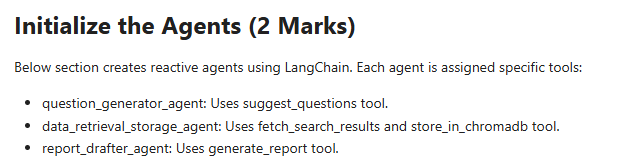

In [ ]:
# Initialize shared memory for tool traces / restarts
#memory =
from langgraph.prebuilt import create_react_agent

# LangGraph memory/checkpointer.
# Memory allows the agent graph to persist intermediate tool traces across a thread.
# Depending on LangGraph version, the class may be called MemorySaver or InMemorySaver.
try:
    from langgraph.checkpoint.memory import MemorySaver
    memory = MemorySaver()
except ImportError:
    from langgraph.checkpoint.memory import InMemorySaver
    memory = InMemorySaver()

# Define the specilized system prompt module for Question Generator Agent
# QUESTION_GEN_MOD =
QUESTION_GEN_MOD = """
You are a Question Generator Agent for a Multi-Agent RAG competitor analysis system.

Your responsibility is to:
1. Validate whether the provided company name is real and known.
2. Identify the company's main industry sector.
3. Generate targeted competitor-analysis questions.
4. Use the suggest_questions tool whenever a company name is provided.
5. Return only useful structured information that can be passed to the next agent.

Focus your questions on:
- Key competitors
- Market share
- Pricing strategy
- Product or service differentiation
- Strengths and weaknesses
- Supply chain and operations
- Customer sentiment
- Technology and innovation
- Market opportunities
- Competitive threats
- Strategic recommendations
"""

# Define the specilized system prompt module for Data Retrieval Storage Agent
# DATA_RETRIEVAL_MOD =
DATA_RETRIEVAL_MOD = """
You are a Data Retrieval and Storage Agent for a Multi-Agent RAG competitor analysis system.

Your responsibility is to:
1. Take the generated competitive-analysis questions.
2. Use the fetch_search_results tool to retrieve current web answers.
3. Use the store_in_chromadb tool to store valid question-answer pairs in ChromaDB.
4. Skip empty or low-value answers.
5. Return the ChromaDB insertion status clearly.

You must use the tools in this order:
1. fetch_search_results
2. store_in_chromadb

Your output should summarize:
- Number of answers retrieved
- Number of records stored
- Whether ChromaDB insertion succeeded or failed
"""

# Define the specilized system prompt module for Report Drafter Agent
# REPORT_DRAFTER_MOD =
REPORT_DRAFTER_MOD = """
You are a Report Drafter Agent for a Multi-Agent RAG competitor analysis system.

Your responsibility is to:
1. Use retrieved vectorstore context supplied by the workflow.
2. Use the generate_report tool to create a professional Markdown report.
3. Structure the report into the required sections:
   - Executive Summary
   - Company Overview
   - Key Competitors
   - Strengths and Weaknesses
   - Market Strategies
   - Recommendations
4. Ensure the report is analytical, actionable, and based primarily on retrieved context.
5. Clearly state when the available context is insufficient.

Do not invent unsupported facts.
"""

**Questions Generator Agent**

In [ ]:
# Create and initilize agent , give it tool(s) and inject system prompt module contract
# question_generator_agent =

# Uses suggest_questions tool.
question_generator_agent = create_react_agent(
    model=llm,
    tools=[suggest_questions],
    prompt=QUESTION_GEN_MOD,
    checkpointer=memory
)

**Data Retrieval & Storage Agent**

In [ ]:
# Create and initilize agent , give it tool(s) and inject system prompt module contract
# data_retrieval_storage_agent =
# Uses fetch_search_results and store_in_chromadb tools.
data_retrieval_storage_agent = create_react_agent(
    model=llm,
    tools=[fetch_search_results, store_in_chromadb],
    prompt=DATA_RETRIEVAL_MOD,
    checkpointer=memory
)

**Report Drafter Agent**

In [ ]:
# Create and initilize agent , give it tool(s) and inject system prompt module contract
#report_drafter_agent =
# Uses generate_report tool.
report_drafter_agent = create_react_agent(
    model=llm,
    tools=[generate_report],
    prompt=REPORT_DRAFTER_MOD,
    checkpointer=memory
)

### **Testing the Generator!!!**

In [ ]:
test_config = {
    "configurable": {
        "thread_id": "competitor-analysis-test"
    }
}

response = question_generator_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Generate 10 competitor analysis questions for Tesla."
            }
        ]
    },
    config=test_config
)

response["messages"][-1].content

[INSIDE TOOL] suggest_questions
[Identified SECTOR] Electric Vehicles and Clean Energy
[IS VALID COMPANY] True
[QUESTION GENERATED LIST] ["Who are Tesla's main direct competitors in the electric vehicle market, and how do their market shares compare?", "How does Tesla's product lineup and technology compare to those of its key competitors?", "What are Tesla's pricing strategies relative to other electric vehicle manufacturers?", "How does Tesla's revenue growth and financial performance compare to its competitors over the past five years?", "What are Tesla's core strengths and weaknesses compared to other players in the electric vehicle and clean energy sectors?", 'How is Tesla perceived by customers and the general public compared to its competitors?', 'What are the key differences in supply chain management and operational efficiency between Tesla and its competitors?', "How does Tesla's innovation pipeline and technology development compare to other companies in the industry?", 'Wha

"Company: Tesla\nIndustry Sector: Electric Vehicles and Clean Energy\nIs Valid Company: Yes\n\nCompetitor Analysis Questions:\n1. Who are Tesla's main direct competitors in the electric vehicle market, and how do their market shares compare?\n2. How does Tesla's product lineup and technology compare to those of its key competitors?\n3. What are Tesla's pricing strategies relative to other electric vehicle manufacturers?\n4. How does Tesla's revenue growth and financial performance compare to its competitors over the past five years?\n5. What are Tesla's core strengths and weaknesses compared to other players in the electric vehicle and clean energy sectors?\n6. How is Tesla perceived by customers and the general public compared to its competitors?\n7. What are the key differences in supply chain management and operational efficiency between Tesla and its competitors?\n8. How does Tesla's innovation pipeline and technology development compare to other companies in the industry?\n9. What

# **Defining the Nodes (18 Marks)**

### **Question Generator Node (6 Marks)**

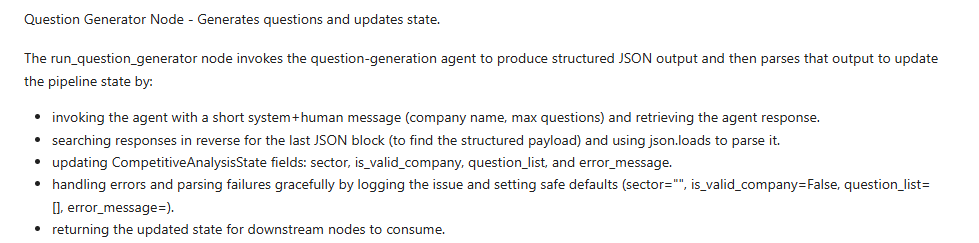

In [ ]:
import json
import re
from langchain_core.messages import SystemMessage, HumanMessage


def extract_json_from_text(text: str) -> dict:
    """
    Extract and parse the last JSON object found in a string.
    Handles plain JSON and JSON inside markdown code blocks.
    """

    if not text:
        raise json.JSONDecodeError("Empty text", text, 0)

    # Remove markdown code fences if present
    cleaned_text = text.strip()
    cleaned_text = cleaned_text.replace("```json", "").replace("```", "").strip()

    # First try direct JSON parsing
    try:
        return json.loads(cleaned_text)
    except json.JSONDecodeError:
        pass

    # Fallback: find JSON-like blocks
    json_blocks = re.findall(r"\{.*\}", cleaned_text, flags=re.DOTALL)

    if not json_blocks:
        raise json.JSONDecodeError("No JSON object found", cleaned_text, 0)

    # Try parsing from the last JSON block backward
    for block in reversed(json_blocks):
        try:
            return json.loads(block)
        except json.JSONDecodeError:
            continue

    raise json.JSONDecodeError("Could not parse JSON block", cleaned_text, 0)

In [ ]:
def run_question_generator(state: CompetitiveAnalysisState) -> CompetitiveAnalysisState:
    """
    Question Generator Node.

    Invokes the question-generation agent, extracts the structured JSON response,
    and updates the CompetitiveAnalysisState with:
    - sector
    - is_valid_company
    - question_list
    - error_message
    """

    print("[NODE]: run_question_generator")

    # Define System and Human Messages
    messages = [
        SystemMessage(
            content=(
                "You are responsible for validating the company name, identifying its sector, "
                "and generating competitive analysis questions. "
                "Use the suggest_questions tool and return the structured JSON output."
            )
        ),
        HumanMessage(
            content=(
                f"Company name: {state.company_name}\n"
                f"Maximum number of questions: {state.max_num_of_questions}\n\n"
                "Generate competitive analysis questions for this company. "
                "Return the final result as JSON with these fields: "
                "sector, is_valid_company, questions, error_message."
            )
        )
    ]

    try:
        # Invoke the question generator agent using the above messages.
        response = question_generator_agent.invoke(
            {
                "messages": messages
            },
            config={
                "configurable": {
                    "thread_id": f"question-generator-{state.company_name}"
                }
            }
        )

        # Find the last message with valid JSON content.
        last_message = None
        parsed_output = None

        # Look through messages in response in reverse order.
        for message in reversed(response.get("messages", [])):
            content = getattr(message, "content", None)

            # If message is a dictionary, handle dictionary-style access too.
            if content is None and isinstance(message, dict):
                content = message.get("content")

            # If content is a string, try parsing it as JSON.
            if isinstance(content, str) and content.strip():
                try:
                    parsed_output = extract_json_from_text(content)
                    last_message = content
                    break
                except json.JSONDecodeError:
                    continue

        # If there is no valid JSON message, use safe defaults.
        if parsed_output is None:
            if response.get("messages"):
                fallback_message = response["messages"][-1]
                last_message = getattr(fallback_message, "content", str(fallback_message))
            else:
                last_message = ""

            print(f"[WARNING]: No valid JSON message found, using last message: {last_message}")

            state.sector = ""
            state.is_valid_company = False
            state.question_list = []
            state.error_message = "Question generation failed: no valid JSON output was found."
            return state

        try:
            # Extract output from parsed JSON object.
            output = parsed_output

            # Get Sector State from output object.
            state.sector = output.get("sector", "")

            # Get Company Validity State from output object.
            state.is_valid_company = output.get("is_valid_company", False)

            # Get Question List State from output object.
            questions = output.get("questions", [])

            if questions is None:
                questions = []

            # Ensure question_list is always a list.
            if not isinstance(questions, list):
                questions = [str(questions)]

            # Respect max question limit.
            state.question_list = questions[: state.max_num_of_questions]

            # Get corrected assignment state for error_message.
            state.error_message = output.get("error_message", None)

            print(
                f"[PARSED OUTPUT]: sector={state.sector}, "
                f"is_valid_company={state.is_valid_company}, "
                f"questions={state.question_list}"
            )

        except Exception as e:
            print(f"[ERROR]: Failed to update state from parsed JSON: {str(e)}")

            state.sector = ""
            state.is_valid_company = False
            state.question_list = []
            state.error_message = f"Failed to update state from parsed JSON: {str(e)}"

    except Exception as e:
        print(f"[ERROR]: Question generator node failed: {str(e)}")

        state.sector = ""
        state.is_valid_company = False
        state.question_list = []
        state.error_message = f"Question generator node failed: {str(e)}"

    return state

### **Testing!!!**

In [ ]:
state = CompetitiveAnalysisState(
    company_name="Tesla",
    vectorstore=vectorstore
)

state = run_question_generator(state)

print("Sector:", state.sector)
print("Is valid company:", state.is_valid_company)
print("Questions:", state.question_list)
print("Error:", state.error_message)

[NODE]: run_question_generator
[INSIDE TOOL] suggest_questions
[Identified SECTOR] Electric Vehicles and Clean Energy
[IS VALID COMPANY] True
[QUESTION GENERATED LIST] ["Who are Tesla's main direct competitors in the electric vehicle market globally?", "How does Tesla's market share in electric vehicles compare to its key competitors?", "What are the primary differences between Tesla's product lineup and those of its competitors?", "How does Tesla's pricing strategy for its vehicles compare to competitors like Ford, GM, and Volkswagen?", "What has been Tesla's revenue growth trend over the past five years compared to its competitors?", "What are Tesla's key strengths that differentiate it from other electric vehicle manufacturers?", 'What weaknesses or challenges does Tesla face relative to its competitors?', 'How is Tesla perceived by customers in terms of brand reputation and product quality?', "What is Tesla's approach to supply chain management, and how does it compare to competito

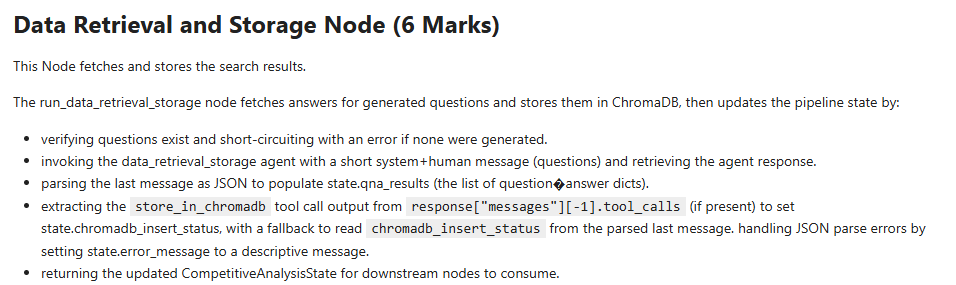

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage

#implementation for the Data Retrieval and Storage Node:
def get_tool_message_content(response: dict, tool_name: str):
    """
    Finds the latest ToolMessage content for a given tool name.
    This is more reliable than looking only at response['messages'][-1].tool_calls,
    because tool_calls usually contain tool arguments, while ToolMessage contains tool output.
    """

    for message in reversed(response.get("messages", [])):
        message_name = getattr(message, "name", None)
        message_content = getattr(message, "content", None)

        if isinstance(message, ToolMessage) and message_name == tool_name:
            return message_content

        # Fallback for dictionary-style messages
        if isinstance(message, dict):
            if message.get("name") == tool_name:
                return message.get("content")

    return None


def get_last_json_message(response: dict):
    """
    Searches response messages in reverse and returns the last parseable JSON object.
    """

    for message in reversed(response.get("messages", [])):
        content = getattr(message, "content", None)

        if content is None and isinstance(message, dict):
            content = message.get("content")

        if isinstance(content, str) and content.strip():
            try:
                return extract_json_from_text(content)
            except json.JSONDecodeError:
                continue

    return None

In [ ]:
def run_data_retrieval_storage(state: CompetitiveAnalysisState) -> CompetitiveAnalysisState:
    """
    Data Retrieval and Storage Node.

    This node:
    1. Verifies that generated questions exist.
    2. Invokes the data_retrieval_storage_agent.
    3. Extracts Q&A results from fetch_search_results tool output.
    4. Extracts ChromaDB insertion status from store_in_chromadb tool output.
    5. Updates the CompetitiveAnalysisState.
    """

    print("[NODE]: run_data_retrieval_storage")

    # Verify questions exist and treat it as an error if none were generated
    if not state.question_list:
        state.error_message = "No questions generated."
        state.qna_results = []
        state.chromadb_insert_status = InsertStatus.FAILED
        print("[ERROR]: No questions generated.")
        return state

    # If previous node found company invalid, short-circuit
    if state.is_valid_company is False:
        state.error_message = state.error_message or "Invalid company name."
        state.qna_results = []
        state.chromadb_insert_status = InsertStatus.FAILED
        print(f"[ERROR]: {state.error_message}")
        return state

    # Define System and Human Messages
    messages = [
        SystemMessage(
            content=(
                "You are responsible for retrieving web answers for competitive analysis questions "
                "and storing valid question-answer pairs in ChromaDB. "
                "Use fetch_search_results first, then store_in_chromadb. "
                "Return a final JSON summary."
            )
        ),
        HumanMessage(
            content=(
                f"Company name: {state.company_name}\n"
                f"Sector: {state.sector}\n\n"
                f"Questions:\n{json.dumps(state.question_list, indent=2)}\n\n"
                "Tasks:\n"
                "1. Call fetch_search_results with the question list.\n"
                "2. Call store_in_chromadb with the Q&A results returned from fetch_search_results.\n"
                "3. Return final JSON with these fields:\n"
                "{\n"
                '  "qna_results": [...],\n'
                '  "chromadb_insert_status": "success" | "failed" | "not_started",\n'
                '  "error_message": null\n'
                "}"
            )
        )
    ]

    try:
        # Invoke the data retrieval and storage agent
        response = data_retrieval_storage_agent.invoke(
            {
                "messages": messages
            },
            config={
                "configurable": {
                    "thread_id": f"data-retrieval-storage-{state.company_name}"
                }
            }
        )

        # ------------------------------------------------------------
        # 1. Extract Q&A results from fetch_search_results tool output
        # ------------------------------------------------------------
        fetch_output = get_tool_message_content(response, "fetch_search_results")

        if fetch_output:
            try:
                qna_results = json.loads(fetch_output)

                if isinstance(qna_results, list):
                    state.qna_results = qna_results
                else:
                    state.qna_results = []

                print(
                    f"[PARSED QNA RESULTS FROM TOOL OUTPUT]: "
                    f"{state.qna_results[:5]}..."
                    if state.qna_results
                    else "No QnA results parsed from tool output."
                )

            except json.JSONDecodeError as e:
                print(f"[ERROR]: Could not parse fetch_search_results output: {str(e)}")
                state.qna_results = []
                state.error_message = f"Could not parse fetch_search_results output: {str(e)}"

        # ------------------------------------------------------------
        # 2. Extract ChromaDB insert status from store_in_chromadb output
        # ------------------------------------------------------------
        store_output = get_tool_message_content(response, "store_in_chromadb")

        if store_output:
            try:
                store_status = json.loads(store_output)

                chroma_status_value = store_status.get(
                    "chromadb_insert_status",
                    InsertStatus.NOT_STARTED.value
                )

                state.chromadb_insert_status = InsertStatus(chroma_status_value)

                print(f"[CHROMADB INSERT STATUS]: {state.chromadb_insert_status}")

            except json.JSONDecodeError as e:
                print(f"[ERROR]: Could not parse store_in_chromadb output: {str(e)}")
                state.chromadb_insert_status = InsertStatus.FAILED
                state.error_message = f"Could not parse store_in_chromadb output: {str(e)}"

            except ValueError:
                print("[ERROR]: Invalid ChromaDB insert status value.")
                state.chromadb_insert_status = InsertStatus.FAILED
                state.error_message = "Invalid ChromaDB insert status value."

        # ------------------------------------------------------------
        # 3. Fallback: parse final agent message if tool outputs were not found
        # ------------------------------------------------------------
        final_json = get_last_json_message(response)

        if final_json:
            if not state.qna_results and "qna_results" in final_json:
                parsed_qna = final_json.get("qna_results", [])
                state.qna_results = parsed_qna if isinstance(parsed_qna, list) else []

            if state.chromadb_insert_status == InsertStatus.NOT_STARTED:
                status_value = final_json.get(
                    "chromadb_insert_status",
                    InsertStatus.NOT_STARTED.value
                )

                try:
                    state.chromadb_insert_status = InsertStatus(status_value)
                except ValueError:
                    state.chromadb_insert_status = InsertStatus.FAILED

            if final_json.get("error_message"):
                state.error_message = final_json.get("error_message")

        # ------------------------------------------------------------
        # 4. Final safety checks
        # ------------------------------------------------------------
        if not state.qna_results:
            state.error_message = state.error_message or "No Q&A results were retrieved."

        if state.chromadb_insert_status == InsertStatus.NOT_STARTED:
            state.chromadb_insert_status = InsertStatus.FAILED
            state.error_message = state.error_message or "ChromaDB insertion was not completed."

    except Exception as e:
        print(f"[ERROR]: Data retrieval and storage node failed: {str(e)}")

        state.qna_results = []
        state.chromadb_insert_status = InsertStatus.FAILED
        state.error_message = f"Data retrieval and storage node failed: {str(e)}"

    return state

In [ ]:
state = CompetitiveAnalysisState(
    company_name="Tesla",
    vectorstore=vectorstore
)

state = run_question_generator(state)
state = run_data_retrieval_storage(state)

print("Q&A Results:", state.qna_results[:2])
print("ChromaDB Status:", state.chromadb_insert_status)
print("Error:", state.error_message)

[NODE]: run_question_generator
[INSIDE TOOL] suggest_questions
[Identified SECTOR] Electric Vehicles and Clean Energy
[IS VALID COMPANY] True
[QUESTION GENERATED LIST] ["Who are Tesla's main direct competitors in the electric vehicle market globally?", 'Which companies compete with Tesla in the renewable energy and battery storage sectors?', "What is Tesla's current global market share in electric vehicles compared to its top competitors?", "How does Tesla's market position vary across different geographic regions?", "What are the key features and differentiators of Tesla's vehicle models compared to competitors?", "How do Tesla's product offerings in energy storage and solar products compare to those of its competitors?", 'What pricing strategies does Tesla employ for its vehicles and energy products?', "How do Tesla's prices compare to those of its main competitors for similar products?", "What has been Tesla's revenue growth trend over the past five years?", "How does Tesla's profit

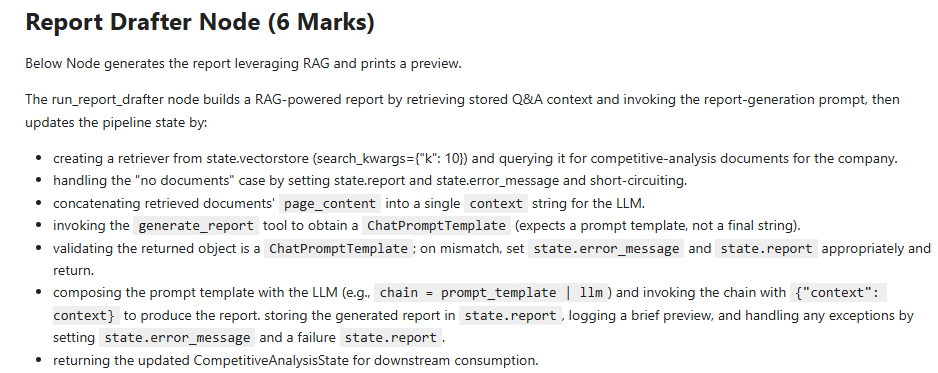

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool


@tool
def generate_report(company_name: str, sector: str) -> ChatPromptTemplate:
    """
    Return a ChatPromptTemplate for generating a competitive analysis report.
    The actual vectorstore context will be injected later by the report drafter node.
    """

    print("[INSIDE TOOL]: generate_report")

    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """
                You are an Advanced Competitor Analysis tool designed to generate detailed,
                data-driven insights on competing companies.

                You analyze competitors based on the provided company_name and sector by
                leveraging retrieved context from a vector database. The retrieved context
                contains answers to targeted questions on competitors, market share,
                strengths, weaknesses, trends, pricing, supply chain, customer sentiment,
                and strategic opportunities.

                Follow these instructions carefully:

                1. Use the provided context as the primary source for all insights.
                2. Compare competitors across:
                   - Market share
                   - Product offerings
                   - Pricing
                   - Technology
                   - Supply chain
                   - Customer sentiment
                   - Brand positioning
                3. Highlight key differentiators such as technological advantages,
                   operational strengths, weaknesses, and strategic gaps.
                4. Identify competitors' strengths to emulate or counter.
                5. Identify competitors' weaknesses to exploit.
                6. Propose actionable strategies such as differentiation tactics,
                   pricing adjustments, targeted marketing, partnerships, and risk mitigation.
                7. Compare competitors to uncover industry trends.
                8. Synthesize findings into a comprehensive market strategy.
                9. Prioritize recommendations by urgency:
                   - Short-term wins
                   - Medium-term improvements
                   - Long-term positioning
                10. Cite or refer to the retrieved context where relevant.

                Structure the final Markdown report with these sections:

                # Executive Summary
                # Company Overview
                # Key Competitors
                # Strengths and Weaknesses
                # Market Strategies
                # Recommendations

                Important:
                - Do not invent facts not supported by the retrieved context.
                - If the retrieved context is insufficient, clearly say what is missing.
                - Keep the tone professional, analytical, and actionable.
                """
            ),
            (
                "human",
                """
                Generate a competitive analysis report.

                Company Name: {company_name}
                Sector: {sector}

                Retrieved Context:
                {context}

                Use the retrieved context to produce a structured, insightful,
                and actionable competitor analysis report.
                """
            )
        ]
    )

    return prompt

In [ ]:
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate


def run_report_drafter(state: CompetitiveAnalysisState) -> CompetitiveAnalysisState:
    """
    Report Drafter Node.

    This node:
    1. Creates a retriever from the Chroma vectorstore.
    2. Retrieves relevant Q&A context.
    3. Invokes the generate_report tool to get a ChatPromptTemplate.
    4. Composes the prompt with the LLM.
    5. Generates and stores the final Markdown report in state.report.
    """

    print("[NODE]: run_report_drafter")

    # Access the globally defined vectorstore if state.vectorstore is missing.
    global vectorstore

    active_vectorstore = state.vectorstore

    if active_vectorstore is None:
        active_vectorstore = vectorstore

    # Validate vectorstore
    if active_vectorstore is None or not isinstance(active_vectorstore, Chroma):
        error_msg = "Valid Chroma vectorstore was not found."

        state.report = error_msg
        state.error_message = error_msg

        print(f"[ERROR]: {error_msg}")

        return state

    try:
        # Construct vector retriever and define top-k parameter
        retriever = active_vectorstore.as_retriever(
            search_kwargs={
                "k": 10
            }
        )

        # Invoke retriever for company stored in CompetitiveAnalysisState
        retrieval_query = (
            f"Competitive analysis documents for {state.company_name} "
            f"in the {state.sector} sector. Include competitors, market share, "
            f"pricing, strengths, weaknesses, strategies, risks, and recommendations."
        )

        retrieved_docs = retriever.invoke(retrieval_query)

        # Handle no documents retrieved
        if not retrieved_docs:
            error_msg = "No data found in vectorstore for report generation."

            state.report = error_msg
            state.error_message = error_msg

            print(f"[ERROR]: {error_msg}")

            return state

        # Create context from retrieved_docs
        context = "\n\n".join(
            [
                f"Context Document {index}\n{doc.page_content}"
                for index, doc in enumerate(retrieved_docs, start=1)
            ]
        )

        print(
            "[RETRIEVED CONTEXT]:",
            context[:200] + "..." if len(context) > 200 else context
        )

        # Directly invoke generate_report tool to get the prompt template
        prompt_template = generate_report.invoke(
            {
                "company_name": state.company_name,
                "sector": state.sector or ""
            }
        )

        # Ensure prompt_template is a ChatPromptTemplate
        if not isinstance(prompt_template, ChatPromptTemplate):
            error_msg = (
                "generate_report did not return a ChatPromptTemplate. "
                f"Returned type: {type(prompt_template)}"
            )

            state.report = error_msg
            state.error_message = error_msg

            print(f"[ERROR]: {error_msg}")

            return state

        # Create a chain using LangChain expression language
        chain = prompt_template | llm

        # Invoke chain with runtime values
        report_content = chain.invoke(
            {
                "company_name": state.company_name,
                "sector": state.sector or "",
                "context": context
            }
        )

        # Store generated report
        state.report = getattr(report_content, "content", str(report_content))

        # Clear error if report generation succeeds
        state.error_message = None

        print(
            "[REPORT GENERATED]:",
            state.report[:200] + "..." if len(state.report) > 200 else state.report
        )

    except Exception as e:
        error_msg = f"Report drafting failed: {str(e)}"

        state.error_message = error_msg
        state.report = error_msg

        print(f"[ERROR]: {error_msg}")

    return state

In [ ]:
state = CompetitiveAnalysisState(
    company_name="Tesla",
    vectorstore=vectorstore
)

state = run_question_generator(state)
state = run_data_retrieval_storage(state)
state = run_report_drafter(state)

print(state.report)

[NODE]: run_question_generator
[INSIDE TOOL] suggest_questions
[Identified SECTOR] Electric Vehicles and Clean Energy
[IS VALID COMPANY] True
[QUESTION GENERATED LIST] ["Who are Tesla's main direct competitors in the electric vehicle market globally?", "How does Tesla's market share in electric vehicles compare to its key competitors?", "What are the primary differences between Tesla's product lineup and those of its competitors?", "How does Tesla's pricing strategy for its vehicles compare to competitors like Ford, GM, and Volkswagen?", "What has been Tesla's revenue growth trend over the past five years compared to its competitors?", "What are Tesla's key strengths in technology and innovation relative to other EV manufacturers?", 'What weaknesses or challenges does Tesla face compared to its competitors?', 'How is Tesla perceived by customers in terms of brand reputation compared to other EV brands?', "What is Tesla's approach to supply chain management and how does it differ from c

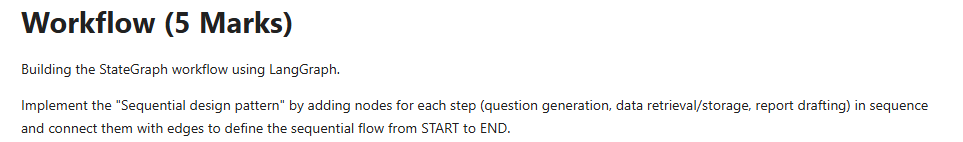

In [ ]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, SVG, Markdown, display


# Initialize StateGraph with CompetitiveAnalysisState schema
graph = StateGraph(CompetitiveAnalysisState)


# Define the required nodes of the graph
graph.add_node("question_generator", run_question_generator)
graph.add_node("data_retrieval_storage", run_data_retrieval_storage)
graph.add_node("report_drafter", run_report_drafter)


# Define edges between nodes to implement the sequential design pattern
graph.add_edge(START, "question_generator")
graph.add_edge("question_generator", "data_retrieval_storage")
graph.add_edge("data_retrieval_storage", "report_drafter")
graph.add_edge("report_drafter", END)


# Compile graph
competitive_analysis = graph.compile()

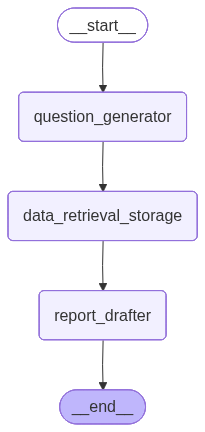

In [ ]:
g = competitive_analysis.get_graph()

try:
    # Preferred: render as PNG
    display(Image(data=g.draw_mermaid_png()))

except Exception as e:
    print(f"[WARN] PNG render failed: {e}")

    try:
        # Fallback: render as SVG
        display(SVG(data=g.draw_mermaid_svg()))

    except Exception as e2:
        print(f"[WARN] SVG render failed: {e2}. Showing Mermaid source instead.")

        # Final fallback: show Mermaid text block
        mermaid_src = g.draw_mermaid()
        display(Markdown(f"```mermaid\n{mermaid_src}\n```"))

In [ ]:
initial_state = CompetitiveAnalysisState(
    company_name="Tesla",
    vectorstore=vectorstore
)

final_state = competitive_analysis.invoke(initial_state)

# print(final_state.report)

[NODE]: run_question_generator
[INSIDE TOOL] suggest_questions
[Identified SECTOR] Electric Vehicles and Clean Energy
[IS VALID COMPANY] True
[QUESTION GENERATED LIST] ["Who are Tesla's main direct competitors in the electric vehicle market globally?", "How does Tesla's market share in electric vehicles compare to its key competitors?", "What are the primary product lines offered by Tesla and how do they differ from competitors' offerings?", "How does Tesla's pricing strategy for its vehicles compare to that of its main competitors?", "What has been Tesla's revenue growth trend over the past five years compared to competitors?", "What are Tesla's key strengths in technology and innovation relative to its competitors?", 'What weaknesses or challenges does Tesla face compared to other electric vehicle manufacturers?', 'How is Tesla perceived by customers in terms of brand reputation compared to competitors?', "What is Tesla's approach to supply chain management and how does it compare to

In [ ]:
final_state = CompetitiveAnalysisState(**final_state)

print(final_state.report)

# Executive Summary

Tesla, a pioneer in electric vehicles (EVs) and clean energy, currently faces intensifying competition from both traditional automakers and emerging Chinese manufacturers, notably BYD. While Tesla maintains strengths in vertical integration, brand recognition, and innovation, its market share and technological advantages are increasingly challenged by rivals closing gaps in battery technology, manufacturing efficiency, and pricing. Regulatory scrutiny and evolving consumer preferences add complexity to Tesla’s competitive landscape. This report analyzes Tesla’s position relative to key competitors, identifies strengths and weaknesses, and proposes prioritized strategies to sustain and grow its market leadership.

# Company Overview

Tesla operates at the intersection of electric vehicles and clean energy solutions, including energy storage and solar markets. Its integrated approach combines vehicle manufacturing, battery technology, and energy products, supported b

# **Execution**

In [ ]:
from IPython.display import Markdown, display

# Sample input -> Tesla, Google, Apple, NVIDIA, Infosys, Deloitte, Great Learning
companyname = "Tesla"

# Invoke the workflow using the given company name
result = competitive_analysis.invoke(
    {
        "company_name": companyname,
        "vectorstore": vectorstore
    }
)

# LangGraph may return either a dict or a CompetitiveAnalysisState object.
# Convert to CompetitiveAnalysisState if needed.
if isinstance(result, dict):
    result = CompetitiveAnalysisState(**result)

# Display final report
if result.report:
    display(Markdown(result.report))
else:
    print("No report generated.")

# Optional: inspect final state
print("Company:", result.company_name)
print("Sector:", result.sector)
print("Valid Company:", result.is_valid_company)
print("ChromaDB Status:", result.chromadb_insert_status)
print("Error:", result.error_message)

[NODE]: run_question_generator
[INSIDE TOOL] suggest_questions
[Identified SECTOR] Electric Vehicles and Clean Energy
[IS VALID COMPANY] True
[QUESTION GENERATED LIST] ["Who are Tesla's main direct competitors in the electric vehicle market globally?", 'Which companies compete with Tesla in the renewable energy and battery storage sectors?', "What is Tesla's current global market share in electric vehicles compared to its key competitors?", "How does Tesla's market position vary across different geographic regions?", "What are the key features and differentiators of Tesla's vehicle models compared to competitors?", "How do Tesla's product offerings in energy storage and solar solutions compare to those of its competitors?", 'What pricing strategies does Tesla employ for its vehicles and energy products?', "How do Tesla's prices compare to those of its main competitors for similar products?", "What has been Tesla's revenue growth trend over the past five years?", "How does Tesla's finan

# Executive Summary

Tesla, a pioneer in electric vehicles (EVs) and clean energy, is experiencing intensifying competition from traditional automakers such as Volkswagen and Ford, as well as Chinese manufacturers like BYD. These competitors are eroding Tesla’s market share by closing technological gaps, offering more affordable alternatives, and leveraging cost advantages. Tesla’s vertical integration in energy storage and solar markets strengthens its position but also faces rising competition and geopolitical risks. Regulatory scrutiny and supply chain challenges further complicate Tesla’s competitive landscape. To sustain its leadership, Tesla must accelerate innovation, optimize pricing strategies, and enhance marketing efforts while mitigating regulatory and operational risks.

# Company Overview

Tesla operates primarily in the electric vehicles and clean energy sectors, with a strong presence in EV manufacturing, battery technology, energy storage, and solar energy solutions. Its brand is synonymous with innovation and sustainability, supported by vertical integration that spans vehicle production to energy products. Tesla’s strategy focuses on technological leadership, expanding production capacity, and developing affordable EV models to capture broader market segments.

# Key Competitors

- **BYD (China):** Offers cost-competitive EVs and is rapidly closing the technological gap with Tesla, particularly in battery technology and manufacturing efficiency. BYD’s local market dominance and pricing strategies pose a significant threat.
- **Traditional Automakers (Volkswagen, Ford):** Leveraging extensive resources, established supply chains, and brand recognition to expand EV offerings. They are aggressively investing in EV technology and production scale.
- **Emerging EV Startups (Rivian):** Challenging Tesla’s technological leadership and market share with innovative products and niche market focus.
- **Other Chinese Manufacturers:** Increasingly competitive in pricing and technology, benefiting from local market advantages and government support.

# Strengths and Weaknesses

**Strengths:**
- Technological leadership in battery technology and autonomous driving (though challenged).
- Vertical integration across EVs, energy storage, and solar markets, enhancing brand recognition and operational control.
- Strong brand equity and investor confidence, despite recent valuation pressures.
- Expanding production capacity and investment in affordable EV models to maintain market share.

**Weaknesses:**
- Declining market share due to aggressive pricing by competitors.
- Rising production costs impacting profit margins.
- Regulatory scrutiny in key markets (U.S., EU, China), especially concerning autonomous driving technology.
- Marketing challenges compared to established automakers with deeper experience in consumer engagement.
- Supply chain vulnerabilities and geopolitical tensions affecting operations.

# Market Strategies

- **Product and Pricing:** Tesla is developing more affordable EV models to counter cost-competitive offerings from Chinese manufacturers and traditional automakers.
- **Technology Investment:** Continued investment in battery technology and manufacturing efficiency to sustain technological leadership.
- **Production Expansion:** Scaling production capacity to meet growing demand and improve economies of scale.
- **Vertical Integration:** Leveraging energy storage and solar business units to create a comprehensive clean energy ecosystem.
- **Regulatory Navigation:** Addressing regulatory challenges through compliance and engagement with authorities in major markets.
- **Brand Positioning:** Emphasizing innovation and sustainability to differentiate from competitors.

# Recommendations

**Short-term Wins:**
- Accelerate launch and marketing of affordable EV models to recapture price-sensitive market segments.
- Enhance customer engagement and marketing efforts to strengthen brand loyalty and counter competitors’ campaigns.
- Proactively address regulatory concerns, particularly around autonomous driving, to mitigate legal and reputational risks.

**Medium-term Improvements:**
- Invest in supply chain diversification and resilience to reduce geopolitical and production risks.
- Expand partnerships with battery suppliers and technology firms to accelerate innovation and cost reduction.
- Optimize production processes to lower costs and improve margins amid rising input prices.

**Long-term Positioning:**
- Deepen vertical integration by expanding energy storage and solar offerings, creating a unique ecosystem that competitors cannot easily replicate.
- Continue R&D in next-generation battery technologies and autonomous systems to maintain technological edge.
- Explore strategic alliances or acquisitions to strengthen market presence in emerging regions and segments.

---

**Note:** The analysis is based solely on the retrieved context provided. Additional data on Tesla’s financials, consumer sentiment metrics, and competitor-specific strategies would enable a more granular assessment.

Company: Tesla
Sector: Electric Vehicles and Clean Energy
Valid Company: True
ChromaDB Status: InsertStatus.SUCCESS
Error: None


In [ ]:
companyname = "Tesla"

result = competitive_analysis.invoke(
    {
        "company_name": companyname,
        "max_num_of_questions": 5,
        "vectorstore": vectorstore
    }
)

if isinstance(result, dict):
    result = CompetitiveAnalysisState(**result)

display(Markdown(result.report))

[NODE]: run_question_generator
[INSIDE TOOL] suggest_questions
[Identified SECTOR] Electric Vehicles and Clean Energy
[IS VALID COMPANY] True
[QUESTION GENERATED LIST] ["Who are Tesla's main direct competitors in the electric vehicle market and how do their market shares compare globally and regionally?", "How does Tesla's product portfolio and technology innovation compare to its key competitors in terms of range, performance, and features?", "What are Tesla's pricing strategies relative to competitors, and how do these impact its market positioning and profitability?", "How does Tesla's brand reputation and customer perception differ from its competitors, and what are the implications for customer loyalty and market growth?", "What are Tesla's strengths and weaknesses in supply chain management and production scalability compared to its competitors, and how might these affect its competitive advantage?"]
[PARSED OUTPUT]: sector=Electric Vehicles and Clean Energy, is_valid_company=Tru

# Executive Summary

Tesla, a pioneer in electric vehicles (EVs) and clean energy, is experiencing intensifying competition from traditional automakers such as Volkswagen and Ford, as well as Chinese manufacturers like BYD and emerging startups including Rivian. These competitors are eroding Tesla’s market share by closing technological gaps, offering more affordable alternatives, and leveraging cost advantages. Tesla’s vertical integration in energy storage and solar markets strengthens its position but also faces rising competitive and geopolitical challenges. Regulatory scrutiny and supply chain risks further complicate Tesla’s landscape. To sustain its leadership, Tesla must accelerate innovation, optimize pricing strategies, and enhance marketing efforts while mitigating regulatory and operational risks.

# Company Overview

Tesla operates at the forefront of the electric vehicle and clean energy sectors, combining automotive manufacturing with energy storage and solar solutions. Its brand recognition and vertical integration provide competitive advantages, enabling control over battery technology and supply chains. Tesla’s strategy includes expanding production capacity, investing heavily in battery innovation, and developing more affordable EV models to broaden market reach. Despite pioneering the EV market, Tesla now confronts significant challenges from well-resourced traditional automakers and cost-competitive Chinese manufacturers.

# Key Competitors

- **BYD (China):** Offers cost-effective EVs with competitive battery technology, leveraging scale and local market advantages to erode Tesla’s market share globally.
- **Volkswagen and Ford (Traditional Automakers):** Utilize extensive resources, established supply chains, and brand loyalty to expand EV offerings rapidly, challenging Tesla’s dominance.
- **Rivian and Emerging Startups:** Focus on niche segments and innovation, posing threats in technology and market share.
- **Other Chinese Manufacturers:** Aggressively expanding EV portfolios with affordable pricing and improving technology.

# Strengths and Weaknesses

| Aspect               | Tesla Strengths                                                                 | Tesla Weaknesses                                                                                   |
|----------------------|--------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------|
| **Market Share**     | Early mover advantage and strong brand recognition in EV and clean energy.     | Declining market share due to aggressive pricing and competition from traditional and Chinese firms. |
| **Product Offerings**| Integrated EV, energy storage, and solar products providing vertical integration.| Limited affordability compared to emerging low-cost competitors.                                 |
| **Pricing**          | Premium pricing supported by technology leadership and brand prestige.          | Struggles to compete on price against cost-effective Chinese manufacturers and traditional automakers. |
| **Technology**       | Leading battery technology and autonomous driving development.                  | Technological edge diminishing as rivals close gaps, especially in battery efficiency and manufacturing. |
| **Supply Chain**     | Vertical integration aids control over key components.                          | Vulnerable to rising production costs and geopolitical supply chain disruptions.                  |
| **Customer Sentiment**| Strong brand loyalty and investor confidence in innovation.                    | Marketing less effective compared to established automakers; regulatory scrutiny impacts perception. |
| **Brand Positioning**| Positioned as a premium, innovative EV and clean energy leader.                 | Faces challenges from competitors with strong local market presence and cost advantages.          |

# Market Strategies

Tesla’s current strategies include:

- **Production Expansion:** Scaling manufacturing to meet growing demand and reduce unit costs.
- **Battery Technology Investment:** Advancing battery innovation to maintain technological leadership and improve vehicle range and cost.
- **Affordable Model Development:** Introducing lower-priced EVs to capture broader market segments and counter competitors’ cost advantages.
- **Vertical Integration:** Leveraging energy storage and solar businesses to create a comprehensive clean energy ecosystem.
- **Regulatory Navigation:** Addressing regulatory challenges through compliance and technology improvements, particularly in autonomous driving.

# Recommendations

### Short-term Wins

- **Adjust Pricing Strategies:** Introduce competitive pricing tiers or incentives to counter low-cost competitors, especially in price-sensitive markets.
- **Enhance Marketing Efforts:** Strengthen marketing campaigns to better communicate Tesla’s technological advantages and brand values, targeting regions with rising competition.
- **Regulatory Compliance:** Proactively engage with regulators to mitigate risks related to autonomous driving and safety standards.

### Medium-term Improvements

- **Accelerate Battery Innovation:** Invest in next-generation battery technologies to regain technological leadership and reduce production costs.
- **Expand Affordable EV Portfolio:** Develop and launch more affordable models tailored to emerging markets and cost-conscious consumers.
- **Supply Chain Diversification:** Mitigate geopolitical and production risks by diversifying suppliers and increasing local sourcing.

### Long-term Positioning

- **Strengthen Vertical Integration:** Deepen integration across EV, energy storage, and solar to create unique value propositions difficult for competitors to replicate.
- **Strategic Partnerships:** Form alliances with technology firms and suppliers to enhance innovation and operational efficiency.
- **Sustain Brand Leadership:** Continue pioneering autonomous driving and clean energy solutions to maintain differentiation and investor confidence.

# Conclusion

Tesla remains a dominant player in the EV and clean energy sectors but faces mounting pressure from traditional automakers and Chinese manufacturers eroding its market share and technological edge. By implementing targeted pricing, marketing, and innovation strategies while managing regulatory and supply chain risks, Tesla can defend and extend its leadership. Prioritizing affordable product development and strengthening vertical integration will be critical for long-term sustainable growth.

---

*This analysis is based solely on the provided context documents and does not incorporate external data.*

In [ ]:
from IPython.display import Markdown, display

report = result["report"] if isinstance(result, dict) else result.report

display(Markdown(report))

# Executive Summary

Tesla, a pioneer in electric vehicles (EVs) and clean energy, is experiencing intensifying competition from traditional automakers such as Volkswagen and Ford, as well as Chinese manufacturers like BYD and emerging startups including Rivian. These competitors are eroding Tesla’s market share by closing technological gaps, offering more affordable alternatives, and leveraging cost advantages. Tesla’s vertical integration in energy storage and solar markets strengthens its position but also faces rising competitive and geopolitical challenges. Regulatory scrutiny and supply chain risks further complicate Tesla’s landscape. To sustain its leadership, Tesla must accelerate innovation, optimize pricing strategies, and enhance marketing efforts while mitigating regulatory and operational risks.

# Company Overview

Tesla operates at the forefront of the electric vehicle and clean energy sectors, combining automotive manufacturing with energy storage and solar solutions. Its brand recognition and vertical integration provide competitive advantages, enabling control over battery technology and supply chains. Tesla’s strategy includes expanding production capacity, investing heavily in battery innovation, and developing more affordable EV models to broaden market reach. Despite pioneering the EV market, Tesla now confronts significant challenges from well-resourced traditional automakers and cost-competitive Chinese manufacturers.

# Key Competitors

- **BYD (China):** Offers cost-effective EVs with competitive battery technology, leveraging scale and local market advantages to erode Tesla’s market share globally.
- **Volkswagen and Ford (Traditional Automakers):** Utilize extensive resources, established supply chains, and brand loyalty to expand EV offerings rapidly, challenging Tesla’s dominance.
- **Rivian and Emerging Startups:** Focus on niche segments and innovation, posing threats in technology and market share.
- **Other Chinese Manufacturers:** Aggressively expanding EV portfolios with affordable pricing and improving technology.

# Strengths and Weaknesses

| Aspect               | Tesla Strengths                                                                 | Tesla Weaknesses                                                                                   |
|----------------------|--------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------|
| **Market Share**     | Early mover advantage and strong brand recognition in EV and clean energy.     | Declining market share due to aggressive pricing and competition from traditional and Chinese firms. |
| **Product Offerings**| Integrated EV, energy storage, and solar products providing vertical integration.| Limited affordability compared to emerging low-cost competitors.                                 |
| **Pricing**          | Premium pricing supported by technology leadership and brand prestige.          | Struggles to compete on price against cost-effective Chinese manufacturers and traditional automakers. |
| **Technology**       | Leading battery technology and autonomous driving development.                  | Technological edge diminishing as rivals close gaps, especially in battery efficiency and manufacturing. |
| **Supply Chain**     | Vertical integration aids control over key components.                          | Vulnerable to rising production costs and geopolitical supply chain disruptions.                  |
| **Customer Sentiment**| Strong brand loyalty and investor confidence in innovation.                    | Marketing less effective compared to established automakers; regulatory scrutiny impacts perception. |
| **Brand Positioning**| Positioned as a premium, innovative EV and clean energy leader.                 | Faces challenges from competitors with strong local market presence and cost advantages.          |

# Market Strategies

Tesla’s current strategies include:

- **Production Expansion:** Scaling manufacturing to meet growing demand and reduce unit costs.
- **Battery Technology Investment:** Advancing battery innovation to maintain technological leadership and improve vehicle range and cost.
- **Affordable Model Development:** Introducing lower-priced EVs to capture broader market segments and counter competitors’ cost advantages.
- **Vertical Integration:** Leveraging energy storage and solar businesses to create a comprehensive clean energy ecosystem.
- **Regulatory Navigation:** Addressing regulatory challenges through compliance and technology improvements, particularly in autonomous driving.

# Recommendations

### Short-term Wins

- **Adjust Pricing Strategies:** Introduce competitive pricing tiers or incentives to counter low-cost competitors, especially in price-sensitive markets.
- **Enhance Marketing Efforts:** Strengthen marketing campaigns to better communicate Tesla’s technological advantages and brand values, targeting regions with rising competition.
- **Regulatory Compliance:** Proactively engage with regulators to mitigate risks related to autonomous driving and safety standards.

### Medium-term Improvements

- **Accelerate Battery Innovation:** Invest in next-generation battery technologies to regain technological leadership and reduce production costs.
- **Expand Affordable EV Portfolio:** Develop and launch more affordable models tailored to emerging markets and cost-conscious consumers.
- **Supply Chain Diversification:** Mitigate geopolitical and production risks by diversifying suppliers and increasing local sourcing.

### Long-term Positioning

- **Strengthen Vertical Integration:** Deepen integration across EV, energy storage, and solar to create unique value propositions difficult for competitors to replicate.
- **Strategic Partnerships:** Form alliances with technology firms and suppliers to enhance innovation and operational efficiency.
- **Sustain Brand Leadership:** Continue pioneering autonomous driving and clean energy solutions to maintain differentiation and investor confidence.

# Conclusion

Tesla remains a dominant player in the EV and clean energy sectors but faces mounting pressure from traditional automakers and Chinese manufacturers eroding its market share and technological edge. By implementing targeted pricing, marketing, and innovation strategies while managing regulatory and supply chain risks, Tesla can defend and extend its leadership. Prioritizing affordable product development and strengthening vertical integration will be critical for long-term sustainable growth.

---

*This analysis is based solely on the provided context documents and does not incorporate external data.*